In [1]:
from pathlib import Path

import torch as tc
import torchvision.transforms.v2 as tvs
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm

from models import ConvNet

RNG = tc.Generator().manual_seed(0)

# FIXME: remove transforms from validation and testing subsets
train_transforms = tvs.Compose([
    tvs.Grayscale(),
    tvs.ToTensor(),
    tvs.ToDtype(tc.float32, scale=True),
    # bit of data augmentation
    # tvs.RandomRotation(360, interpolation="bilinear"),
    # tvs.RandomVerticalFlip(),
    tvs.RandomHorizontalFlip(),
    tvs.GaussianNoise(sigma=0.2),
    # tvs.Resize(100),
    tvs.RandomResizedCrop(100, scale=(0.5, 1)),
    # tvs.RandomCrop((224 // 2, 224 // 2)),
    tvs.Normalize(mean=(0.5,), std=(0.5,)), # TODO: compute statistics from dataset instead
])
test_transforms = tvs.Compose([
    tvs.ToImage(),
    tvs.ToDtype(tc.uint8, scale=True),
    tvs.Grayscale(),
    # tvs.ConvertImageDtype(tc.float32),
    tvs.ToDtype(tc.float32, scale=True),
    tvs.Resize(100),
    tvs.Normalize(mean=(0.5,), std=(0.5,)), # TODO: compute statistics from dataset instead
])

dataset = ImageFolder("data/cats_and_dogs/PetImages", transform=train_transforms)
# scaled from original data shape (1, 224, 224)
SHAPE = (1, 100, 100)

import numpy as np

print(dataset.classes)
class_labels = np.array(dataset.targets)
class_0_count = np.count_nonzero(class_labels == 0)
class_1_count = np.count_nonzero(class_labels == 1)
print(dataset.classes[0], ":", class_0_count)
print(dataset.classes[1], ":", class_1_count)

['Cat', 'Dog']
Cat : 12499
Dog : 12499


c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:
BATCH_SIZE: int = 500
WORKERS: int = 4

devel_dataset, test_dataset = tc.utils.data.random_split(dataset, [0.8, 0.2], generator=RNG)

device = tc.device("cuda")

model = ConvNet(shape=SHAPE).to(device)
print(model)

ConvNet(
  (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(4, 4))
  (conv1): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(4, 4))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11):

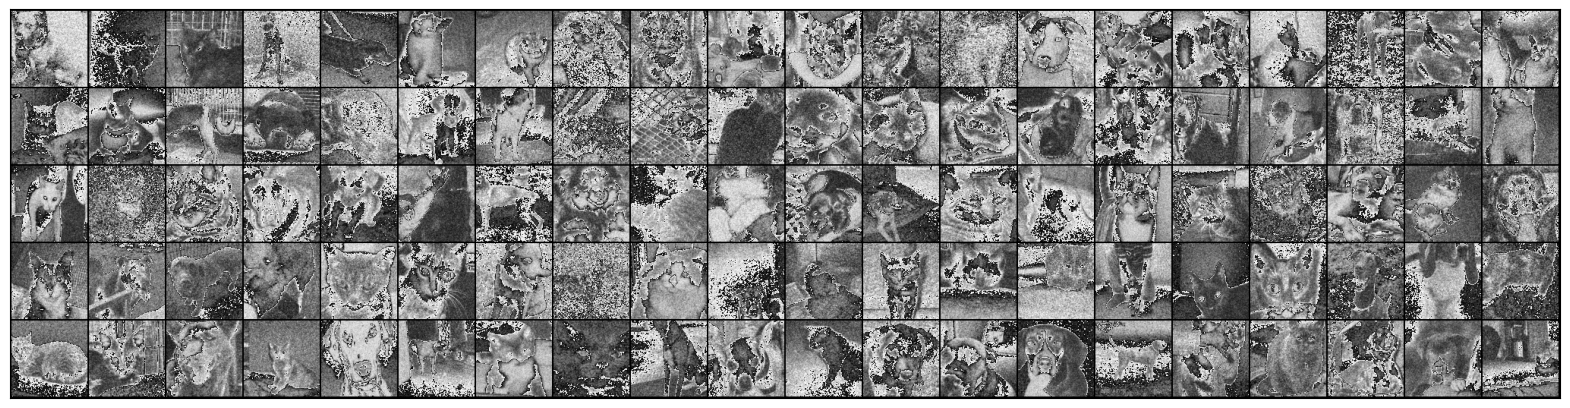

In [3]:
from torchvision.utils import make_grid
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torchvision.transforms.functional as F

examples = tc.stack([devel_dataset[i][0] for i in range(100)])

def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fix, axs = plt.subplots(squeeze=False, figsize=(20, 20))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

grid = make_grid(examples, nrow=20)
show(grid)


Class imbalance: tensor(1., dtype=torch.float64)
Epoch: 0


Train on batches: 100%|██████████| 32/32 [00:16<00:00,  1.96it/s]


Train - Loss: 1.3724, Acc: 0.5311, F1: 0.4670
Valid - Loss: 0.6829, Acc: 0.5534, F1: 0.5525


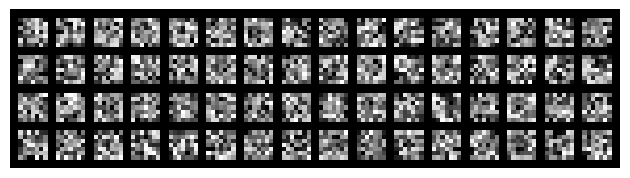

Epoch: 1


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.14it/s]


Train - Loss: 0.6843, Acc: 0.5612, F1: 0.5515
Valid - Loss: 0.6797, Acc: 0.5764, F1: 0.5663
Epoch: 2


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.14it/s]


Train - Loss: 0.6812, Acc: 0.5713, F1: 0.5641
Valid - Loss: 0.6774, Acc: 0.5826, F1: 0.5746
Epoch: 3


...

Train - Loss: 0.6723, Acc: 0.5931, F1: 0.5742
Valid - Loss: 0.6665, Acc: 0.6027, F1: 0.5895
Epoch: 9


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.18it/s]


Train - Loss: 0.6585, Acc: 0.6134, F1: 0.6076
Valid - Loss: 0.6421, Acc: 0.6214, F1: 0.6182
Epoch: 10


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.6473, Acc: 0.6236, F1: 0.6184
Valid - Loss: 0.6349, Acc: 0.6379, F1: 0.6304


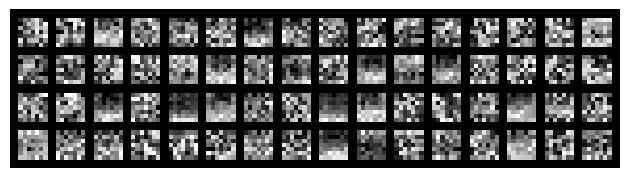

Epoch: 11


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.6370, Acc: 0.6403, F1: 0.6389
Valid - Loss: 0.6176, Acc: 0.6569, F1: 0.6552
Epoch: 12


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.6308, Acc: 0.6447, F1: 0.6416
Valid - Loss: 0.6298, Acc: 0.6444, F1: 0.6276
Epoch: 13


...

Train - Loss: 0.5819, Acc: 0.6949, F1: 0.6934
Valid - Loss: 0.5660, Acc: 0.7199, F1: 0.7188
Epoch: 19


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.5842, Acc: 0.6965, F1: 0.6939
Valid - Loss: 0.5484, Acc: 0.7242, F1: 0.7226
Epoch: 20


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.5685, Acc: 0.7094, F1: 0.7083
Valid - Loss: 0.5418, Acc: 0.7307, F1: 0.7301


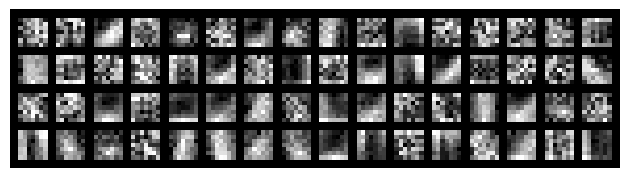

Epoch: 21


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.5616, Acc: 0.7082, F1: 0.7068
Valid - Loss: 0.5339, Acc: 0.7287, F1: 0.7284
Epoch: 22


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.5500, Acc: 0.7234, F1: 0.7217
Valid - Loss: 0.5208, Acc: 0.7392, F1: 0.7390
Epoch: 23


...

Train - Loss: 0.5155, Acc: 0.7473, F1: 0.7470
Valid - Loss: 0.4935, Acc: 0.7624, F1: 0.7620
Epoch: 29


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.17it/s]


Train - Loss: 0.5123, Acc: 0.7472, F1: 0.7468
Valid - Loss: 0.4934, Acc: 0.7594, F1: 0.7588
Epoch: 30


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.5122, Acc: 0.7514, F1: 0.7505
Valid - Loss: 0.4989, Acc: 0.7487, F1: 0.7464


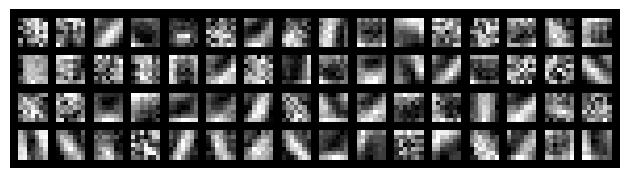

Epoch: 31


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.17it/s]


Train - Loss: 0.5078, Acc: 0.7508, F1: 0.7489
Valid - Loss: 0.4824, Acc: 0.7704, F1: 0.7685
Epoch: 32


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


Train - Loss: 0.5007, Acc: 0.7625, F1: 0.7614
Valid - Loss: 0.4713, Acc: 0.7739, F1: 0.7738
Epoch: 33


...

Train - Loss: 0.4667, Acc: 0.7740, F1: 0.7737
Valid - Loss: 0.4535, Acc: 0.7822, F1: 0.7820
Epoch: 39


Train on batches: 100%|██████████| 32/32 [00:15<00:00,  2.13it/s]


Train - Loss: 0.4605, Acc: 0.7809, F1: 0.7806
Valid - Loss: 0.4516, Acc: 0.7869, F1: 0.7867
Epoch: 40


Train on batches: 100%|██████████| 32/32 [00:15<00:00,  2.13it/s]


Train - Loss: 0.4766, Acc: 0.7724, F1: 0.7711
Valid - Loss: 0.4393, Acc: 0.7912, F1: 0.7910


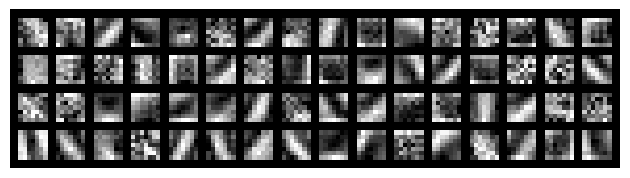

Epoch: 41


Train on batches: 100%|██████████| 32/32 [00:15<00:00,  2.12it/s]


Train - Loss: 0.4674, Acc: 0.7768, F1: 0.7759
Valid - Loss: 0.4282, Acc: 0.7919, F1: 0.7919
Epoch: 42


Train on batches: 100%|██████████| 32/32 [00:14<00:00,  2.13it/s]


Train - Loss: 0.4619, Acc: 0.7799, F1: 0.7795
Valid - Loss: 0.4372, Acc: 0.7982, F1: 0.7976
Epoch: 43


...

Train - Loss: 0.4355, Acc: 0.7997, F1: 0.7993
Valid - Loss: 0.4133, Acc: 0.8084, F1: 0.8081
Epoch: 49


Train on batches: 100%|██████████| 32/32 [00:17<00:00,  1.87it/s]


Train - Loss: 0.4280, Acc: 0.7989, F1: 0.7988
Valid - Loss: 0.4362, Acc: 0.7869, F1: 0.7843
Epoch: 50


Train on batches: 100%|██████████| 32/32 [00:17<00:00,  1.87it/s]


Train - Loss: 0.4379, Acc: 0.7939, F1: 0.7934
Valid - Loss: 0.4176, Acc: 0.8059, F1: 0.8048


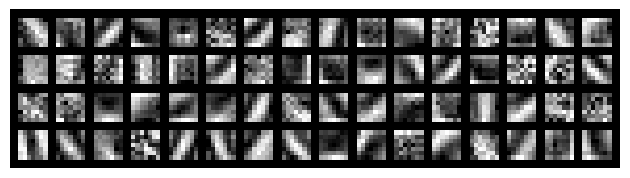

Epoch: 51


Train on batches: 100%|██████████| 32/32 [00:16<00:00,  1.94it/s]


Train - Loss: 0.4368, Acc: 0.7968, F1: 0.7963
Valid - Loss: 0.4182, Acc: 0.8082, F1: 0.8073
Epoch: 52


Train on batches: 100%|██████████| 32/32 [00:15<00:00,  2.05it/s]


Train - Loss: 0.4275, Acc: 0.7954, F1: 0.7952
Valid - Loss: 0.4026, Acc: 0.8082, F1: 0.8082
Epoch: 53


...

Train - Loss: 0.4152, Acc: 0.8077, F1: 0.8074
Valid - Loss: 0.4020, Acc: 0.8185, F1: 0.8180
Epoch: 59


Train on batches: 100%|██████████| 32/32 [00:21<00:00,  1.47it/s]


Train - Loss: 0.4198, Acc: 0.8048, F1: 0.8040
Valid - Loss: 0.3883, Acc: 0.8170, F1: 0.8168
Epoch: 60


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.39it/s]


Train - Loss: 0.4107, Acc: 0.8079, F1: 0.8076
Valid - Loss: 0.3865, Acc: 0.8227, F1: 0.8223


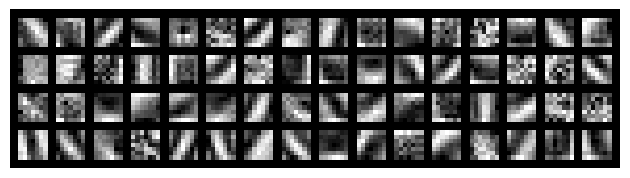

Epoch: 61


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.39it/s]


Train - Loss: 0.4103, Acc: 0.8081, F1: 0.8080
Valid - Loss: 0.3885, Acc: 0.8237, F1: 0.8237
Epoch: 62


Train on batches: 100%|██████████| 32/32 [00:20<00:00,  1.53it/s]


Train - Loss: 0.4127, Acc: 0.8107, F1: 0.8103
Valid - Loss: 0.3959, Acc: 0.8175, F1: 0.8166
Epoch: 63


...

Train - Loss: 0.4048, Acc: 0.8182, F1: 0.8180
Valid - Loss: 0.3829, Acc: 0.8277, F1: 0.8276
Epoch: 69


Train on batches: 100%|██████████| 32/32 [00:19<00:00,  1.60it/s]


Train - Loss: 0.4026, Acc: 0.8163, F1: 0.8160
Valid - Loss: 0.3811, Acc: 0.8202, F1: 0.8198
Epoch: 70


Train on batches: 100%|██████████| 32/32 [00:20<00:00,  1.56it/s]


Train - Loss: 0.3939, Acc: 0.8159, F1: 0.8157
Valid - Loss: 0.3824, Acc: 0.8290, F1: 0.8287


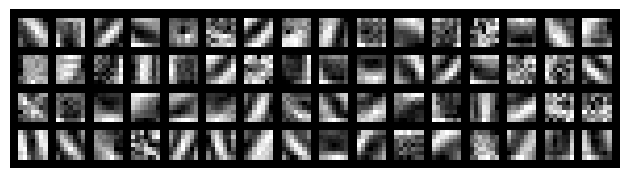

Epoch: 71


Train on batches: 100%|██████████| 32/32 [00:19<00:00,  1.65it/s]


Train - Loss: 0.3979, Acc: 0.8157, F1: 0.8155
Valid - Loss: 0.3673, Acc: 0.8342, F1: 0.8342
Epoch: 72


Train on batches: 100%|██████████| 32/32 [00:18<00:00,  1.69it/s]


Train - Loss: 0.3939, Acc: 0.8171, F1: 0.8165
Valid - Loss: 0.3769, Acc: 0.8310, F1: 0.8308
Epoch: 73


...

Train - Loss: 0.3885, Acc: 0.8184, F1: 0.8183
Valid - Loss: 0.3631, Acc: 0.8325, F1: 0.8324
Epoch: 79


Train on batches: 100%|██████████| 32/32 [00:20<00:00,  1.55it/s]


Train - Loss: 0.3841, Acc: 0.8231, F1: 0.8230
Valid - Loss: 0.3716, Acc: 0.8332, F1: 0.8330
Epoch: 80


Train on batches: 100%|██████████| 32/32 [00:20<00:00,  1.60it/s]


Train - Loss: 0.3830, Acc: 0.8251, F1: 0.8249
Valid - Loss: 0.3569, Acc: 0.8317, F1: 0.8315


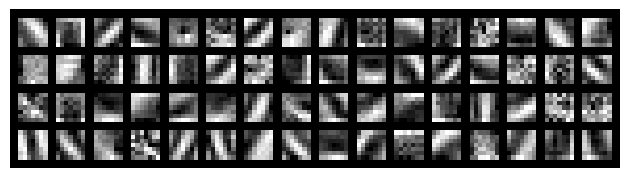

Epoch: 81


Train on batches: 100%|██████████| 32/32 [00:20<00:00,  1.57it/s]


Train - Loss: 0.3788, Acc: 0.8261, F1: 0.8260
Valid - Loss: 0.3597, Acc: 0.8385, F1: 0.8385
Epoch: 82


Train on batches: 100%|██████████| 32/32 [00:19<00:00,  1.64it/s]


Train - Loss: 0.3810, Acc: 0.8271, F1: 0.8270
Valid - Loss: 0.3581, Acc: 0.8372, F1: 0.8372
Epoch: 83


...

Train - Loss: 0.3716, Acc: 0.8305, F1: 0.8303
Valid - Loss: 0.3541, Acc: 0.8390, F1: 0.8385
Epoch: 89


Train on batches: 100%|██████████| 32/32 [00:21<00:00,  1.52it/s]


Train - Loss: 0.3727, Acc: 0.8291, F1: 0.8290
Valid - Loss: 0.3525, Acc: 0.8390, F1: 0.8390
Epoch: 90


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.44it/s]


Train - Loss: 0.3715, Acc: 0.8317, F1: 0.8315
Valid - Loss: 0.3806, Acc: 0.8175, F1: 0.8147


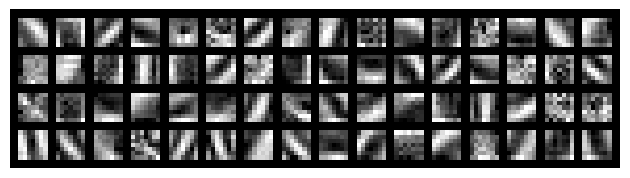

Epoch: 91


Train on batches: 100%|██████████| 32/32 [00:21<00:00,  1.50it/s]


Train - Loss: 0.3685, Acc: 0.8319, F1: 0.8318
Valid - Loss: 0.3595, Acc: 0.8377, F1: 0.8376
Epoch: 92


Train on batches: 100%|██████████| 32/32 [00:21<00:00,  1.47it/s]


Train - Loss: 0.3715, Acc: 0.8313, F1: 0.8312
Valid - Loss: 0.3464, Acc: 0.8365, F1: 0.8363
Epoch: 93


...

Train - Loss: 0.3625, Acc: 0.8357, F1: 0.8357
Valid - Loss: 0.3475, Acc: 0.8457, F1: 0.8457
Epoch: 99


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.33it/s]


Train - Loss: 0.3620, Acc: 0.8357, F1: 0.8355
Valid - Loss: 0.3343, Acc: 0.8547, F1: 0.8546
Epoch: 100


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.34it/s]


Train - Loss: 0.3586, Acc: 0.8361, F1: 0.8356
Valid - Loss: 0.3471, Acc: 0.8430, F1: 0.8423


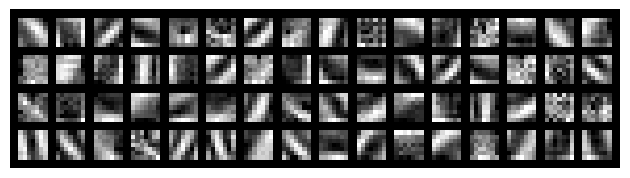

Epoch: 101


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.34it/s]


Train - Loss: 0.3636, Acc: 0.8373, F1: 0.8369
Valid - Loss: 0.3465, Acc: 0.8425, F1: 0.8420
Epoch: 102


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]


Train - Loss: 0.3593, Acc: 0.8392, F1: 0.8392
Valid - Loss: 0.3343, Acc: 0.8487, F1: 0.8484
Epoch: 103


...

Train - Loss: 0.3540, Acc: 0.8396, F1: 0.8394
Valid - Loss: 0.3249, Acc: 0.8557, F1: 0.8557
Epoch: 109


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.40it/s]


Train - Loss: 0.3465, Acc: 0.8433, F1: 0.8432
Valid - Loss: 0.3303, Acc: 0.8567, F1: 0.8566
Epoch: 110


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.39it/s]


Train - Loss: 0.3523, Acc: 0.8444, F1: 0.8443
Valid - Loss: 0.3296, Acc: 0.8545, F1: 0.8544


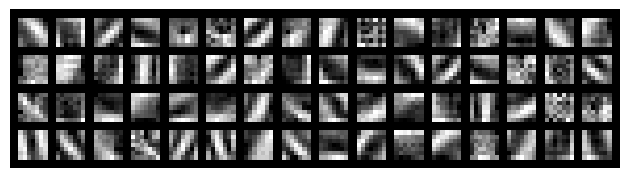

Epoch: 111


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.37it/s]


Train - Loss: 0.3508, Acc: 0.8360, F1: 0.8359
Valid - Loss: 0.3566, Acc: 0.8352, F1: 0.8344
Epoch: 112


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.37it/s]


Train - Loss: 0.3573, Acc: 0.8357, F1: 0.8355
Valid - Loss: 0.3319, Acc: 0.8555, F1: 0.8554
Epoch: 113


...

Train - Loss: 0.3465, Acc: 0.8437, F1: 0.8436
Valid - Loss: 0.3263, Acc: 0.8562, F1: 0.8562
Epoch: 119


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.36it/s]


Train - Loss: 0.3384, Acc: 0.8484, F1: 0.8483
Valid - Loss: 0.3283, Acc: 0.8572, F1: 0.8571
Epoch: 120


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.34it/s]


Train - Loss: 0.3401, Acc: 0.8468, F1: 0.8467
Valid - Loss: 0.3254, Acc: 0.8550, F1: 0.8550


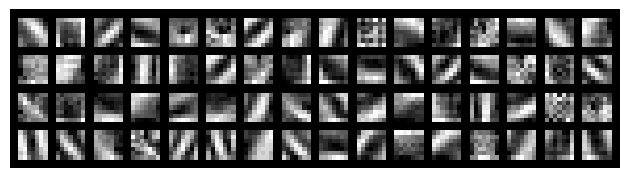

Epoch: 121


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.34it/s]


Train - Loss: 0.3482, Acc: 0.8452, F1: 0.8452
Valid - Loss: 0.3035, Acc: 0.8610, F1: 0.8610
Epoch: 122


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.35it/s]


Train - Loss: 0.3389, Acc: 0.8486, F1: 0.8486
Valid - Loss: 0.3209, Acc: 0.8537, F1: 0.8534
Epoch: 123


...

Train - Loss: 0.3325, Acc: 0.8500, F1: 0.8499
Valid - Loss: 0.3227, Acc: 0.8595, F1: 0.8594
Epoch: 129


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.40it/s]


Train - Loss: 0.3368, Acc: 0.8468, F1: 0.8467
Valid - Loss: 0.3246, Acc: 0.8527, F1: 0.8524
Epoch: 130


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.40it/s]


Train - Loss: 0.3299, Acc: 0.8520, F1: 0.8519
Valid - Loss: 0.3225, Acc: 0.8540, F1: 0.8540


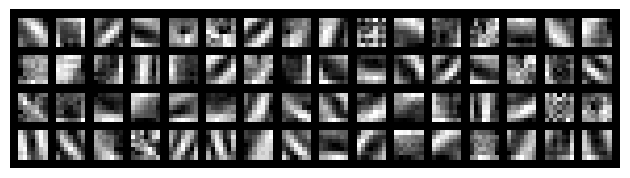

Epoch: 131


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.41it/s]


Train - Loss: 0.3291, Acc: 0.8547, F1: 0.8546
Valid - Loss: 0.3215, Acc: 0.8572, F1: 0.8569
Epoch: 132


Train on batches: 100%|██████████| 32/32 [00:22<00:00,  1.41it/s]


Train - Loss: 0.3384, Acc: 0.8476, F1: 0.8473
Valid - Loss: 0.3330, Acc: 0.8535, F1: 0.8531
Epoch: 133


...

Train - Loss: 0.3284, Acc: 0.8527, F1: 0.8526
Valid - Loss: 0.3032, Acc: 0.8652, F1: 0.8652
Epoch: 139


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.32it/s]


Train - Loss: 0.3231, Acc: 0.8570, F1: 0.8570
Valid - Loss: 0.3201, Acc: 0.8565, F1: 0.8564
Epoch: 140


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.31it/s]


Train - Loss: 0.3196, Acc: 0.8572, F1: 0.8572
Valid - Loss: 0.3162, Acc: 0.8587, F1: 0.8585


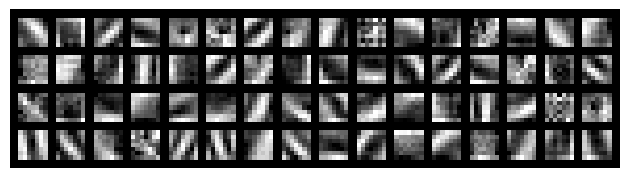

Epoch: 141


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.30it/s]


Train - Loss: 0.3208, Acc: 0.8595, F1: 0.8595
Valid - Loss: 0.3104, Acc: 0.8577, F1: 0.8577
Epoch: 142


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]


Train - Loss: 0.3251, Acc: 0.8522, F1: 0.8522
Valid - Loss: 0.3129, Acc: 0.8600, F1: 0.8600
Epoch: 143


...

Train - Loss: 0.3231, Acc: 0.8551, F1: 0.8550
Valid - Loss: 0.3043, Acc: 0.8665, F1: 0.8664
Epoch: 149


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.35it/s]


Train - Loss: 0.3211, Acc: 0.8574, F1: 0.8573
Valid - Loss: 0.3007, Acc: 0.8635, F1: 0.8634
Epoch: 150


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.35it/s]


Train - Loss: 0.3163, Acc: 0.8604, F1: 0.8604
Valid - Loss: 0.3057, Acc: 0.8647, F1: 0.8646


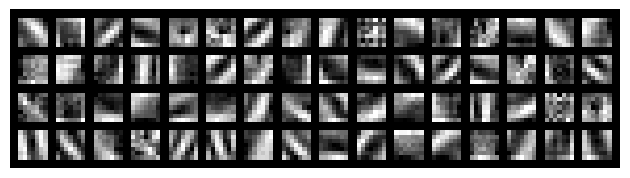

Epoch: 151


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.36it/s]


Train - Loss: 0.3214, Acc: 0.8575, F1: 0.8575
Valid - Loss: 0.3080, Acc: 0.8577, F1: 0.8576
Epoch: 152


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.36it/s]


Train - Loss: 0.3211, Acc: 0.8573, F1: 0.8572
Valid - Loss: 0.3003, Acc: 0.8622, F1: 0.8622
Epoch: 153


...

Train - Loss: 0.3115, Acc: 0.8635, F1: 0.8635
Valid - Loss: 0.3000, Acc: 0.8697, F1: 0.8698
Epoch: 159


Train on batches: 100%|██████████| 32/32 [00:25<00:00,  1.26it/s]


Train - Loss: 0.3083, Acc: 0.8613, F1: 0.8613
Valid - Loss: 0.3053, Acc: 0.8677, F1: 0.8676
Epoch: 160


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.28it/s]


Train - Loss: 0.3128, Acc: 0.8603, F1: 0.8603
Valid - Loss: 0.3052, Acc: 0.8617, F1: 0.8617


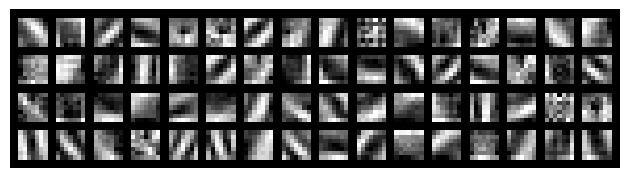

Epoch: 161


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.28it/s]


Train - Loss: 0.3125, Acc: 0.8626, F1: 0.8625
Valid - Loss: 0.2983, Acc: 0.8662, F1: 0.8662
Epoch: 162


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]


Train - Loss: 0.3112, Acc: 0.8596, F1: 0.8596
Valid - Loss: 0.3087, Acc: 0.8607, F1: 0.8607
Epoch: 163


...

Train - Loss: 0.3046, Acc: 0.8614, F1: 0.8613
Valid - Loss: 0.3038, Acc: 0.8710, F1: 0.8709
Epoch: 169


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.36it/s]


Train - Loss: 0.3107, Acc: 0.8624, F1: 0.8624
Valid - Loss: 0.3049, Acc: 0.8630, F1: 0.8629
Epoch: 170


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.37it/s]


Train - Loss: 0.3109, Acc: 0.8612, F1: 0.8613
Valid - Loss: 0.3045, Acc: 0.8625, F1: 0.8624


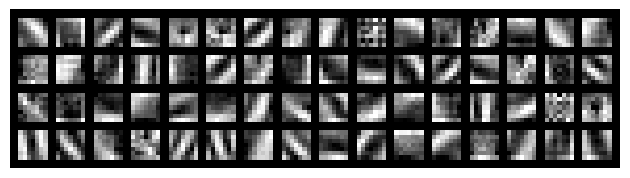

Epoch: 171


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.35it/s]


Train - Loss: 0.3105, Acc: 0.8624, F1: 0.8623
Valid - Loss: 0.2985, Acc: 0.8685, F1: 0.8685
Epoch: 172


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.33it/s]


Train - Loss: 0.3052, Acc: 0.8672, F1: 0.8672
Valid - Loss: 0.2982, Acc: 0.8650, F1: 0.8648
Epoch: 173


...

Train - Loss: 0.3088, Acc: 0.8645, F1: 0.8645
Valid - Loss: 0.2899, Acc: 0.8727, F1: 0.8727
Epoch: 179


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.31it/s]


Train - Loss: 0.3075, Acc: 0.8632, F1: 0.8632
Valid - Loss: 0.3033, Acc: 0.8607, F1: 0.8605
Epoch: 180


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.31it/s]


Train - Loss: 0.3049, Acc: 0.8672, F1: 0.8672
Valid - Loss: 0.3002, Acc: 0.8685, F1: 0.8684


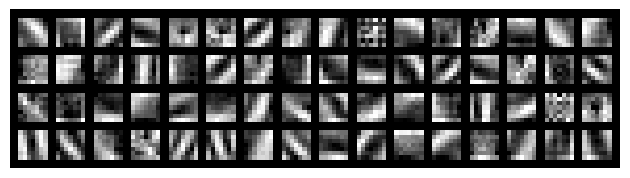

Epoch: 181


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.32it/s]


Train - Loss: 0.3051, Acc: 0.8621, F1: 0.8621
Valid - Loss: 0.2967, Acc: 0.8657, F1: 0.8656
Epoch: 182


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.31it/s]


Train - Loss: 0.3052, Acc: 0.8632, F1: 0.8632
Valid - Loss: 0.2952, Acc: 0.8667, F1: 0.8666
Epoch: 183


...

Train - Loss: 0.3053, Acc: 0.8661, F1: 0.8660
Valid - Loss: 0.3000, Acc: 0.8710, F1: 0.8709
Epoch: 189


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.35it/s]


Train - Loss: 0.3038, Acc: 0.8654, F1: 0.8654
Valid - Loss: 0.2940, Acc: 0.8672, F1: 0.8672
Epoch: 190


Train on batches: 100%|██████████| 32/32 [00:23<00:00,  1.34it/s]


Train - Loss: 0.3039, Acc: 0.8687, F1: 0.8687
Valid - Loss: 0.3017, Acc: 0.8670, F1: 0.8669


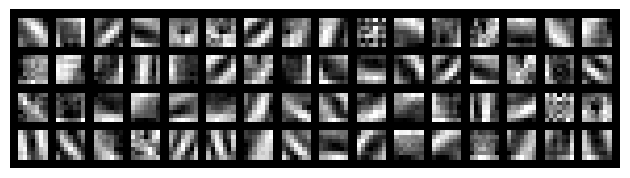

Epoch: 191


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.32it/s]


Train - Loss: 0.3053, Acc: 0.8626, F1: 0.8626
Valid - Loss: 0.2960, Acc: 0.8677, F1: 0.8676
Epoch: 192


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.32it/s]


Train - Loss: 0.3014, Acc: 0.8674, F1: 0.8674
Valid - Loss: 0.2930, Acc: 0.8697, F1: 0.8697
Epoch: 193


...

Train - Loss: 0.3029, Acc: 0.8655, F1: 0.8655
Valid - Loss: 0.2967, Acc: 0.8695, F1: 0.8694
Epoch: 198


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.32it/s]


Train - Loss: 0.3069, Acc: 0.8647, F1: 0.8647
Valid - Loss: 0.3042, Acc: 0.8637, F1: 0.8637
Epoch: 199


Train on batches: 100%|██████████| 32/32 [00:24<00:00,  1.32it/s]


Train - Loss: 0.3100, Acc: 0.8619, F1: 0.8619
Valid - Loss: 0.2936, Acc: 0.8690, F1: 0.8689


In [4]:
from sklearn.metrics import accuracy_score, f1_score

EPOCHS: int = 200


# apply weight decay only to convolution layers
decaying = []
not_decaying = []
for m in model.modules():
    if isinstance(m, (tc.nn.Linear, tc.nn.Conv2d)):
        decaying.append(m.weight)
        not_decaying.append(m.bias)
    elif hasattr(m, 'weight'):
        not_decaying.append(m.weight)
    elif hasattr(m, 'bias'):
        not_decaying.append(m.bias)

grouped_parameters = [
    {"params": decaying, "weight_decay": 0.01},
    {"params": not_decaying, "weight_decay": 0.0}
]

# handle unbalanced dataset
pos_weight = tc.tensor(class_0_count / class_1_count)
print("Class imbalance:", pos_weight)
criterion = tc.nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device)
optimizer = tc.optim.AdamW(grouped_parameters, lr=0.01)
scheduler = tc.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

acc_train = []; f1_train = []; loss_train = []
acc_valid = []; f1_valid = []; loss_valid = []

train_subset, valid_subset = tc.utils.data.random_split(devel_dataset, [0.8, 0.2], generator=RNG)
train_loader = DataLoader(
    train_subset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=WORKERS,
    pin_memory=True,
)
valid_loader = DataLoader(
    valid_subset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=WORKERS,
    pin_memory=True,
)

# for epoch in tqdm(range(EPOCHS), "Training"):
for epoch in range(EPOCHS):
    print(f"Epoch: {epoch}")

    # training phase
    running_loss = []
    running_acc = []
    running_f1 = []
    model.train()
    for images, labels in tqdm(train_loader, "Train on batches"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze(dim=-1)
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()

        # Compute accuracy, and F1-score
        # predicted = tc.argmax(outputs, dim=-1)
        predicted = tc.sigmoid(outputs).round().detach()
        running_loss.append(loss.item())
        running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
        running_f1.append(f1_score(labels.cpu(), predicted.cpu(), average="weighted"))
        # print("Batch accuracy score", accuracy_score(labels.cpu(), predicted.cpu()))

    loss_train.append(np.mean(running_loss))
    acc_train.append(np.mean(running_acc))
    f1_train.append(np.mean(running_f1))
    print(f"Train - Loss: {loss_train[epoch]:.4f}, Acc: {acc_train[epoch]:.4f}, F1: {f1_train[epoch]:.4f}")

    # validation phase
    model.eval()
    running_loss = []
    running_acc = []
    running_f1 = []
    with tc.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze(dim=-1)
            loss = criterion(outputs, labels.float())

            # predicted = tc.argmax(outputs, dim=-1)
            predicted = tc.sigmoid(outputs).round().detach()
            running_loss.append(loss.item())
            running_acc.append(accuracy_score(labels.cpu(), predicted.cpu()))
            running_f1.append(
                f1_score(labels.cpu(), predicted.cpu(), average="weighted")
            )

        loss_valid.append(np.mean(running_loss))
        acc_valid.append(np.mean(running_acc))
        f1_valid.append(np.mean(running_f1))
        print(f"Valid - Loss: {loss_valid[epoch]:.4f}, Acc: {acc_valid[epoch]:.4f}, F1: {f1_valid[epoch]:.4f}")


    import torchvision
    if epoch % 10 == 0:
        fig, ax = plt.subplots()
        image = torchvision.utils.make_grid(model.conv0.weight.detach().cpu(), nrow=16, normalize=True, scale_each=True)
        # bring channel axis to the last place
        ax.imshow(image.numpy().transpose((1, 2, 0)))
        ax.axis("off")
        fig.tight_layout()
        plt.show()

    # bookkeping
    scheduler.step()

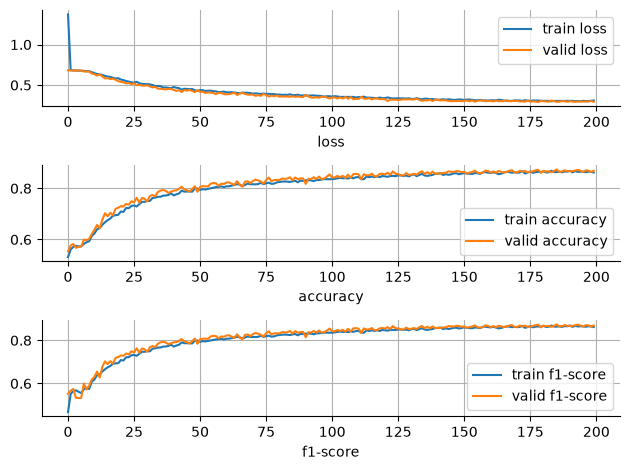

In [5]:
# plot metrics traces
import seaborn as sns

fix, axes = plt.subplots(nrows=3)

sns.lineplot(loss_train, label="train loss", ax=axes[0])
sns.lineplot(loss_valid, label="valid loss", ax=axes[0])
axes[0].set_xlabel("epoch")
axes[0].set_xlabel("loss")
sns.despine(ax=axes[0])
axes[0].grid()

sns.lineplot(acc_train, label="train accuracy", ax=axes[1])
sns.lineplot(acc_valid, label="valid accuracy", ax=axes[1])
axes[1].set_xlabel("epoch")
axes[1].set_xlabel("accuracy")
sns.despine(ax=axes[1])
axes[1].grid()

sns.lineplot(f1_train, label="train f1-score", ax=axes[2])
sns.lineplot(f1_valid, label="valid f1-score", ax=axes[2])
axes[2].set_xlabel("epoch")
axes[2].set_xlabel("f1-score")
sns.despine(ax=axes[2])
axes[2].grid()

plt.tight_layout()
plt.show()

Test Accuracy: 0.8708, Test F1-score: 0.8707


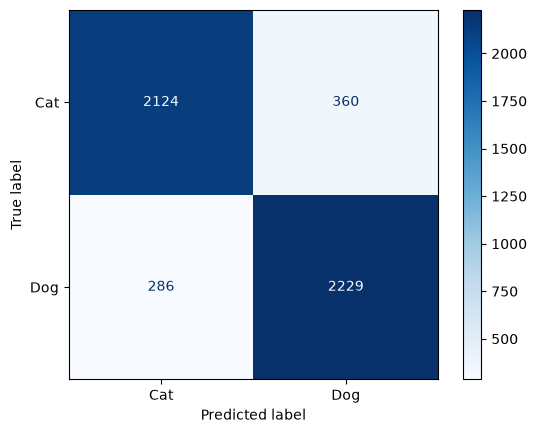

In [6]:
# test the model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=WORKERS,
    pin_memory=True,
)

def test_model(model: tc.nn.Module, loader: DataLoader):
    model.eval()
    test_pred_labels = []
    test_true_labels = []
    with tc.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(dim=-1)
            # predicted = tc.argmax(outputs, dim=-1)
            predicted = tc.sigmoid(outputs).round().detach()
            test_pred_labels.extend(predicted.cpu().numpy())
            test_true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(test_true_labels, test_pred_labels)
    f1 = f1_score(test_true_labels, test_pred_labels, average='weighted')
    print(f'Test Accuracy: {accuracy:.4f}, Test F1-score: {f1:.4f}')

    cm = confusion_matrix(test_true_labels, test_pred_labels)
    cmd = ConfusionMatrixDisplay(cm, display_labels=dataset.classes)
    cmd.plot(cmap=plt.cm.Blues)

test_model(model, test_loader)

torch.Size([64, 1, 7, 7])


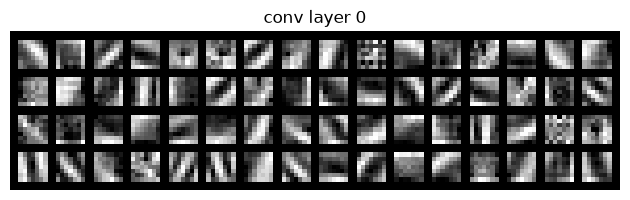

In [7]:
# visualize filters
import matplotlib.pyplot as plt
import torchvision

# for i, layer in enumerate([model.conv0.weight, model.conv1.weight]):
#     print(layer.shape)
#     fig, ax = plt.subplots()
#     ax.set_title(f"conv layer {i}")
#     filters = layer.view(-1, *layer.shape[-2:]).unsqueeze(dim=1)
#     image = torchvision.utils.make_grid(filters.cpu(), nrow=16, normalize=True, scale_each=True)
#     # bring channel axis to the last place
#     ax.imshow(image.numpy().transpose((1, 2, 0)))
#     ax.axis("off")
#     fig.tight_layout()

print(model.conv0.weight.shape)
fig, ax = plt.subplots()
ax.set_title(f"conv layer 0")
filters = model.conv0.weight.view(-1, *model.conv0.weight.shape[-2:]).unsqueeze(dim=1)
image = torchvision.utils.make_grid(filters.cpu(), nrow=16, normalize=True, scale_each=True)
# bring channel axis to the last place
ax.imshow(image.numpy().transpose((1, 2, 0)))
ax.axis("off")
fig.tight_layout()

In [ ]:
# export the trained model

save_folder = Path("./weights")
save_folder.mkdir(exist_ok=True)
tc.save(model.state_dict(), Path(save_folder, f"{model.name}_{EPOCHS}.pt"))